In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from pathlib import Path

SCHED_DIR  = Path('outputs/scheduler_outputs')
CPS        = 100_000_000
DURATION_S = 10.0

# ── hardware order ────────────────────────────────────────────────────────────
HOMO_HW_ORDER   = ['mono128', 'comp4x64', 'comp16x32', 'comp64x16']
HETERO_HW_ORDER = ['hetero1', 'hetero2', 'hetero3']
ALL_HW_ORDER    = HOMO_HW_ORDER + HETERO_HW_ORDER
HW_LABELS = {
    'mono128':   'SA128',         'comp4x64':  'SA64',
    'comp16x32': 'SA32',         'comp64x16': 'SA16',
    'hetero1':   'Hetero1',          'hetero2':   'Hetero2',
    'hetero3':   'Hetero3',
}
HW_ORDER = HOMO_HW_ORDER  # backward compat

# ── alloc parsing (longest-match substring) ───────────────────────────────────
HOMO_ALLOC_VALUES = {'greedy', 'fair', 'deadline_fold'}
HETERO_WAFF_TAGS  = ['hetero_W25', 'hetero_W50', 'hetero_W75']
ALL_ALLOC_VALUES  = HOMO_ALLOC_VALUES | set(HETERO_WAFF_TAGS)
ALLOC_VALUES = {'greedy', 'fair'}  # kept for reference

def _parse_alloc(stem: str) -> str:
    for tag in sorted(ALL_ALLOC_VALUES, key=len, reverse=True):
        if tag in stem:
            return tag
    return 'model'

# ── LP key constants ──────────────────────────────────────────────────────────
# deadline changed to red so orange is exclusively for hetero bars
LP_KEYS   = ['fifo_greedy', 'lpt_greedy', 'deadline_greedy']
LP_LABELS = {'fifo_greedy': 'FIFO', 'lpt_greedy': 'LPT', 'deadline_greedy': 'Deadline'}
LP_COLORS = {'fifo_greedy': '#4878d0', 'lpt_greedy': '#6acc65', 'deadline_greedy': '#ff7f0e'}

HETERO_LP_KEYS   = ['deadline_hetero_W25', 'deadline_hetero_W50', 'deadline_hetero_W75']
HETERO_LP_LABELS = {
    'deadline_hetero_W25': 'Hetero W_aff=0.25',
    'deadline_hetero_W50': 'Hetero W_aff=0.50',
    'deadline_hetero_W75': 'Hetero W_aff=0.75',
}
HETERO_COLOR   = '#ff7f0e'          # all hetero bars share this orange
HETERO_HATCHES = ['.', '//', '*']   # dots, diagonal lines, stars
HETERO_EDGE    = '#555555'          # hatch line color

THROUGHPUT_MODELS = ['emformer', 'mobilellm_125m']
LATENCY_MODELS    = ['hand_pose', 'eyecod', 'key_res15', 'tcn', 'd2go', 'deit_small']

# ── load summary CSVs ─────────────────────────────────────────────────────────
summaries = []
for p in sorted(SCHED_DIR.glob('xrbench_*_summary.csv')):
    alloc = _parse_alloc(p.stem)
    if alloc == 'model':
        continue
    df = pd.read_csv(p)
    df['alloc'] = alloc
    summaries.append(df)

sched_all = pd.concat(summaries, ignore_index=True)
sched_all = sched_all[sched_all['scenario'] == 'xrbench_8model'].copy()
sched_all['lp_key'] = (
    sched_all['policy'].str.replace('deadline_task_aware', 'deadline', regex=False)
    + '_' + sched_all['alloc']
)

# ── load trace CSVs ───────────────────────────────────────────────────────────
POL_ORDER = ['fifo', 'lpt', 'deadline_task_aware']
traces = []
for path in sorted(SCHED_DIR.glob('*8model*_trace.csv')):
    alloc = _parse_alloc(path.stem)
    if alloc == 'model':
        continue
    hw  = next((h for h in ALL_HW_ORDER if h in path.stem), None)
    pol = next((p for p in POL_ORDER if p in path.stem), None)
    if hw is None or pol is None:
        continue
    lp_key = f"{pol.replace('deadline_task_aware', 'deadline')}_{alloc}"
    df = pd.read_csv(path)
    df['hardware'] = hw
    df['lp_key']   = lp_key
    if 'mode' not in df.columns:
        df['mode'] = df['model'].map(
            lambda m: 'throughput' if m in THROUGHPUT_MODELS else 'latency')
    traces.append(df)

trace = pd.concat(traces, ignore_index=True)

# ── helper: filter trace to a hw-set × lp-set ────────────────────────────────
def _sub(hw_list, lp_list):
    return trace[trace['hardware'].isin(hw_list) & trace['lp_key'].isin(lp_list)].copy()

def _lat_stats(t, hw_order, lp_list):
    lat   = t[t['mode'] == 'latency'].copy()
    hit   = lat[lat['deadline_miss'] == 0].copy()
    hit['response_ms'] = hit['response_cycles'] / CPS * 1000
    resp  = hit.groupby(['hardware','lp_key']).agg(mean_resp_ms=('response_ms','mean')).reset_index()
    miss  = lat.groupby(['hardware','lp_key']).agg(miss_pct=('deadline_miss', lambda x: x.mean()*100)).reset_index()
    merged = resp.merge(miss, on=['hardware','lp_key'])
    lat_p  = merged.pivot(index='hardware', columns='lp_key', values='mean_resp_ms').reindex(hw_order)
    miss_p = merged.pivot(index='hardware', columns='lp_key', values='miss_pct').reindex(hw_order)
    return lat_p, miss_p, lat, hit

def _tp_counts(t, hw_order, lp_list):
    tp = t[(t['mode']=='throughput') & (t['deadline_miss']==0)].copy()
    cnt = tp.groupby(['hardware','lp_key','model']).size().reset_index(name='completions')
    cnt['throughput_rps'] = cnt['completions'] / DURATION_S
    return cnt

def _util_pivot(hw_order, lp_list):
    sub = sched_all[sched_all['hardware'].isin(hw_order) & sched_all['lp_key'].isin(lp_list)]
    return sub.pivot_table(index='hardware', columns='lp_key',
                           values='pe_utilization', aggfunc='first').reindex(hw_order)

# ── homo stats ────────────────────────────────────────────────────────────────
trace_homo = _sub(HOMO_HW_ORDER, LP_KEYS)
lat_piv, miss_piv, lat_all, lat_hit = _lat_stats(trace_homo, HW_ORDER, LP_KEYS)
tp_counts  = _tp_counts(trace_homo, HW_ORDER, LP_KEYS)
util_pivot = _util_pivot(HW_ORDER, LP_KEYS)

# ── hetero stats ──────────────────────────────────────────────────────────────
trace_hetero = _sub(HETERO_HW_ORDER, HETERO_LP_KEYS)
lat_piv_h, miss_piv_h, lat_all_h, lat_hit_h = _lat_stats(trace_hetero, HETERO_HW_ORDER, HETERO_LP_KEYS)
tp_counts_h  = _tp_counts(trace_hetero, HETERO_HW_ORDER, HETERO_LP_KEYS)
util_pivot_h = _util_pivot(HETERO_HW_ORDER, HETERO_LP_KEYS)

print(f"Homo  — latency arrivals: {len(lat_all):,}  on-time: {len(lat_hit):,}")
print(f"Hetero— latency arrivals: {len(lat_all_h):,}  on-time: {len(lat_hit_h):,}")
print("\nMiss rate preview (homo):")
print(miss_piv.round(1).to_string())
if not miss_piv_h.empty:
    print("\nMiss rate preview (hetero):")
    print(miss_piv_h.round(1).to_string())


Homo  — latency arrivals: 30,000  on-time: 28,002
Hetero— latency arrivals: 22,500  on-time: 22,238

Miss rate preview (homo):
lp_key     deadline_greedy  fifo_greedy  lpt_greedy
hardware                                           
mono128                6.1         16.3        33.4
comp4x64               0.8          2.6         4.7
comp16x32              1.8          2.1         2.7
comp64x16              2.8          3.4         3.3

Miss rate preview (hetero):
lp_key    deadline_hetero_W25  deadline_hetero_W50  deadline_hetero_W75
hardware                                                               
hetero1                   0.9                  1.0                  1.6
hetero2                   0.2                  0.7                  0.7
hetero3                   1.6                  1.7                  2.0


In [ ]:
plt.rcParams.update({
    'font.size':        12,
    'axes.titlesize':   13,
    'axes.labelsize':   13,
    'xtick.labelsize':  11,
    'ytick.labelsize':  11,
    'legend.fontsize':  10,
    'axes.titlepad':     6,
    'figure.dpi':       120,
})

x_all   = np.arange(len(ALL_HW_ORDER))
w       = 0.27
offsets = np.array([-1, 0, 1]) * w

def _getv(piv, hw, lp):
    try:
        v = float(piv.at[hw, lp])
        return None if np.isnan(v) else v
    except (KeyError, ValueError):
        return None

def bar_group_v2(ax, homo_piv, hetero_piv, fmt=None, log_scale=False,
                 mono128_only_labels=False):
    all_vals = []
    for hw in ALL_HW_ORDER:
        is_homo = hw in HOMO_HW_ORDER
        piv = homo_piv if is_homo else hetero_piv
        lps = LP_KEYS if is_homo else HETERO_LP_KEYS
        for lp in lps:
            v = _getv(piv, hw, lp)
            if v is not None:
                all_vals.append(v)
    vmax = max(all_vals) if all_vals else 1.0

    for j, hw in enumerate(ALL_HW_ORDER):
        is_homo = hw in HOMO_HW_ORDER
        lps = LP_KEYS if is_homo else HETERO_LP_KEYS
        piv = homo_piv if is_homo else hetero_piv
        for i, lp in enumerate(lps):
            v = _getv(piv, hw, lp)
            if v is None:
                continue
            xpos = x_all[j] + offsets[i]
            if is_homo:
                ax.bar(xpos, v, w, color=LP_COLORS[lp],
                       edgecolor='white', linewidth=0.4)
            else:
                ax.bar(xpos, v, w, color=HETERO_COLOR,
                       hatch=HETERO_HATCHES[i], edgecolor=HETERO_EDGE, linewidth=0.4)
            if fmt and (not mono128_only_labels or hw == 'mono128'):
                yoff = vmax * 0.025 if not log_scale else v * 0.04
                ax.text(xpos, v + yoff, fmt % v,
                        ha='center', va='bottom', fontsize=11)

    ax.axvline(len(HOMO_HW_ORDER) - 0.5, color='grey',
               linestyle=':', linewidth=1.1, alpha=0.7)
    ax.set_xticks(x_all)
    ax.set_xticklabels([HW_LABELS[h] for h in ALL_HW_ORDER], fontsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.margins(x=0.04)

    legend_els = [
        Patch(facecolor=LP_COLORS['fifo_greedy'],    edgecolor='white', label='FIFO'),
        Patch(facecolor=LP_COLORS['lpt_greedy'],      edgecolor='white', label='LPT'),
        Patch(facecolor=LP_COLORS['deadline_greedy'], edgecolor='white', label='Deadline'),
        Patch(facecolor=HETERO_COLOR, hatch=HETERO_HATCHES[0],
              edgecolor=HETERO_EDGE, label='Hetero  W=0.25'),
        Patch(facecolor=HETERO_COLOR, hatch=HETERO_HATCHES[1],
              edgecolor=HETERO_EDGE, label='Hetero  W=0.50'),
        Patch(facecolor=HETERO_COLOR, hatch=HETERO_HATCHES[2],
              edgecolor=HETERO_EDGE, label='Hetero  W=0.75'),
    ]
    ax.legend(handles=legend_els, ncol=2, framealpha=0.85,
              handlelength=1.5, handletextpad=0.5, columnspacing=0.8, fontsize=12)
    return legend_els


# Fig 1 -- Average Response Latency
fig1, ax1 = plt.subplots(figsize=(11, 4))
bar_group_v2(ax1, lat_piv, lat_piv_h, log_scale=True)
ax1.set_ylabel('Mean Response Time (ms)')
ax1.set_xlabel('Hardware Config')
ax1.set_title('Avg Response Latency -- Latency-Sensitive Models')
ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.2f}'))
plt.tight_layout(pad=0.5)
plt.savefig('outputs/latency.pdf', bbox_inches='tight')
plt.show()


# Fig 2 -- Deadline Miss Rate (y-axis capped at 10%)
YLIM_MISS = 10.5   # bars above this are clipped; actual values annotated inside

fig2, ax2 = plt.subplots(figsize=(11, 4))
bar_group_v2(ax2, miss_piv, miss_piv_h)
ax2.set_ylabel('Deadline Miss Rate (%)')
ax2.set_xlabel('Hardware Config')
ax2.set_title('Deadline Miss Rate -- Latency-Sensitive Models  (deadline_scale=0.5)')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.set_ylim(0, YLIM_MISS)

# Annotate SA128 FIFO and LPT bars whose true values exceed the y cutoff
_mono_j = ALL_HW_ORDER.index('mono128')
for i, lp_key in enumerate(['fifo_greedy', 'lpt_greedy']):
    val = _getv(miss_piv, 'mono128', lp_key)
    if val is not None and val > YLIM_MISS:
        xpos = x_all[_mono_j] + offsets[i]
        ax2.text(xpos, YLIM_MISS - 0.25, f'{val:.1f}%',
                 ha='center', va='top', fontsize=9.5,
                 rotation=90, color='white', fontweight='bold')

plt.tight_layout(pad=0.5)
plt.savefig('outputs/miss_rate.pdf', bbox_inches='tight')
plt.show()


# Fig 3 -- Throughput
fig3, axes3 = plt.subplots(1, 2, figsize=(16, 3.5), sharey=False)

legend_els = None
for ax, model in zip(axes3, THROUGHPUT_MODELS):
    homo_tp = (tp_counts[tp_counts['model'] == model]
               .pivot(index='hardware', columns='lp_key', values='throughput_rps')
               .reindex(index=HOMO_HW_ORDER, columns=LP_KEYS)
               .fillna(0))
    hetero_tp = (tp_counts_h[tp_counts_h['model'] == model]
                 .pivot(index='hardware', columns='lp_key', values='throughput_rps')
                 .reindex(index=HETERO_HW_ORDER, columns=HETERO_LP_KEYS)
                 .fillna(0))
    legend_els = bar_group_v2(ax, homo_tp, hetero_tp, fmt='%.1f',
                              mono128_only_labels=True)
    ax.get_legend().remove()  # will be replaced by shared legend below
    if model == THROUGHPUT_MODELS[0]:
        ax.set_ylabel('Throughput (req/s)')
    ax.set_title(model, fontweight='bold')

fig3.suptitle('Throughput -- Best-Effort Models (no deadline, fill idle capacity)',
              fontweight='bold')
fig3.legend(handles=legend_els, ncol=6, loc='lower center',
            bbox_to_anchor=(0.5, -0.12), framealpha=0.9,
            handlelength=1.5, handletextpad=0.5, columnspacing=1.0, fontsize=11)
plt.tight_layout(pad=0.5)
plt.savefig('outputs/throughput.pdf', bbox_inches='tight')
plt.show()


# Fig 4 -- PE Utilization
util_pct   = util_pivot   * 100
util_pct_h = util_pivot_h * 100

all_util  = pd.concat([util_pct, util_pct_h])
ylim_util = max(50.0, float(all_util.max().max()) * 1.25)

fig4, ax4 = plt.subplots(figsize=(11, 4))
bar_group_v2(ax4, util_pct, util_pct_h, fmt='%.0f%%')
ax4.set_ylabel('PE Utilization (%)')
ax4.set_xlabel('Hardware Config')
ax4.set_title('PE Utilization -- MappingEff x ComputeUtil x Temporal Occupancy')
ax4.yaxis.set_major_formatter(mticker.PercentFormatter())
ax4.set_ylim(0, ylim_util)
plt.tight_layout(pad=0.5)
plt.savefig('outputs/utilization.pdf', bbox_inches='tight')
plt.show()


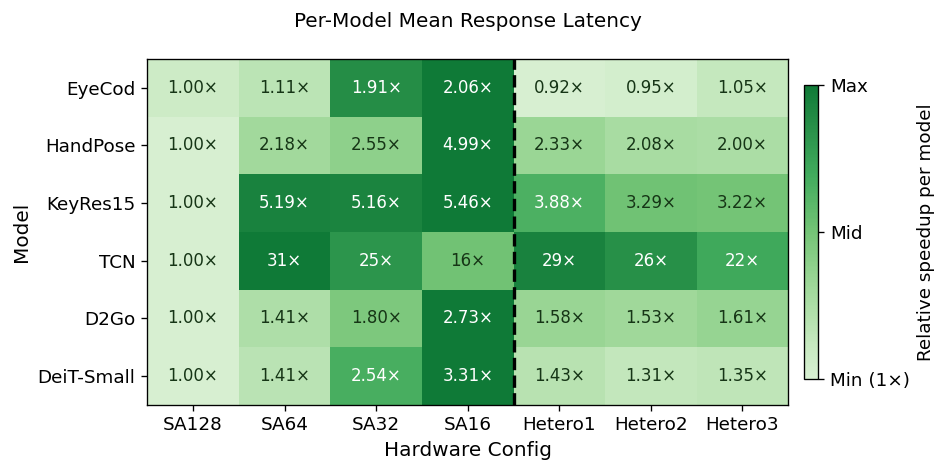

In [3]:
# ── Fig 5 : Per-model latency heatmap (speedup over mono128) ──────────────────
# Policy: deadline_task_aware + deadline_fold (homo), + hetero_W50 (hetero).
# Speedup = mono128_mean_response / hw_mean_response  (higher → lower latency → more green).
# Color is per-row normalized so each model uses the full green range independently
# (avoids mobilellm_125m's 400x speedup washing out the latency model differences).
# Cell annotations show the actual speedup value.

from matplotlib.colors import LinearSegmentedColormap

HEATMAP_LP = {
    'mono128':   'deadline_deadline_fold',
    'comp4x64':  'deadline_deadline_fold',
    'comp16x32': 'deadline_deadline_fold',
    'comp64x16': 'deadline_deadline_fold',
    'hetero1':   'deadline_hetero_W50',
    'hetero2':   'deadline_hetero_W50',
    'hetero3':   'deadline_hetero_W50',
}

HM_MODEL_ORDER = ['eyecod', 'hand_pose', 'key_res15', 'tcn', 'd2go', 'deit_small',]
HM_MODEL_LABELS = {
    'eyecod':          'EyeCod',
    'hand_pose':       'HandPose',
    'key_res15':       'KeyRes15',
    'tcn':             'TCN',
    'd2go':            'D2Go',
    'deit_small':      'DeiT-Small',
}

# Per-(hw, model) mean response time (ms), all completed requests
mean_resp_cols = {}
for hw, lp_key in HEATMAP_LP.items():
    sub = trace[(trace['hardware'] == hw) & (trace['lp_key'] == lp_key)].copy()
    sub['response_ms'] = sub['response_cycles'] / CPS * 1000
    mean_resp_cols[hw] = sub.groupby('model')['response_ms'].mean()

resp_df = pd.DataFrame(mean_resp_cols).reindex(index=HM_MODEL_ORDER, columns=ALL_HW_ORDER)

# Actual speedup values (for annotations)
mono_vals   = resp_df['mono128'].values.reshape(-1, 1)
speedup_arr = mono_vals / resp_df.values          # shape: (n_models, n_hw)

# Per-row normalize to [0, 1] so each model uses the full green range
row_min = speedup_arr.min(axis=1, keepdims=True)
row_max = speedup_arr.max(axis=1, keepdims=True)
data_norm = (speedup_arr - row_min) / np.where(row_max > row_min, row_max - row_min, 1.0)

# Clipped Greens: sample [0.18, 0.82] to avoid near-white and near-black extremes
green_mid = LinearSegmentedColormap.from_list(
    'green_mid', plt.cm.Greens(np.linspace(0.18, 0.82, 256))
)

fig5, ax5 = plt.subplots(figsize=(8, 4))
im = ax5.imshow(data_norm, cmap=green_mid, aspect='auto', vmin=0.0, vmax=1.0)

# Annotate every cell with actual speedup; flip text colour at midpoint
for i in range(len(HM_MODEL_ORDER)):
    for j in range(len(ALL_HW_ORDER)):
        v_actual = speedup_arr[i, j]
        v_norm   = data_norm[i, j]
        txt_color = 'white' if v_norm > 0.55 else '#163516'
        label = f'{v_actual:.0f}×' if v_actual >= 10 else f'{v_actual:.2f}×'
        ax5.text(j, i, label, ha='center', va='center',
                 fontsize=10, color=txt_color)

# Dashed separator: latency models / throughput models
n_lat = len(LATENCY_MODELS)
# ax5.axhline(n_lat - 0.5, color='black', linewidth=2, linestyle='--')
# Solid separator: homogeneous / heterogeneous configs
ax5.axvline(len(HOMO_HW_ORDER) - 0.5, color='black', linewidth=2, linestyle='--')

ax5.set_xticks(range(len(ALL_HW_ORDER)))
ax5.set_xticklabels([HW_LABELS[h] for h in ALL_HW_ORDER], fontsize=11)
ax5.set_yticks(range(len(HM_MODEL_ORDER)))
ax5.set_yticklabels([HM_MODEL_LABELS[m] for m in HM_MODEL_ORDER], fontsize=11)

cbar = plt.colorbar(im, ax=ax5, shrink=0.85, pad=0.02)
cbar.set_label('Relative speedup per model', fontsize=11) #   (per-row normalized)
cbar.set_ticks([0.0, 0.5, 1.0])
cbar.set_ticklabels(['Min (1×)', 'Mid', 'Max'])

ax5.set_title(
    'Per-Model Mean Response Latency\n',
    # 'Colour normalized per row  |  Policy: deadline_task_aware + deadline_fold  |  † = throughput / best-effort', — Speedup over mono128 (1×SA128)
    fontsize=12, # pad=2,
)
ax5.set_xlabel('Hardware Config', fontsize=12)
ax5.set_ylabel('Model', fontsize=12)

plt.tight_layout(pad=0.8)
plt.savefig('outputs/latency_heatmap.pdf', bbox_inches='tight')
plt.show()


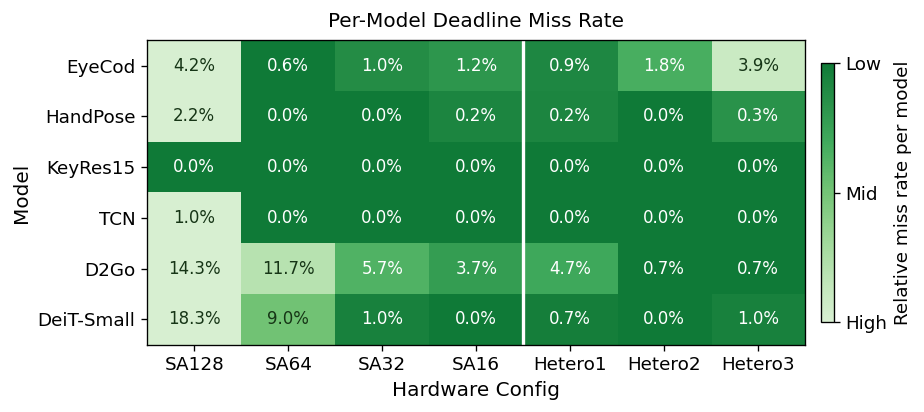

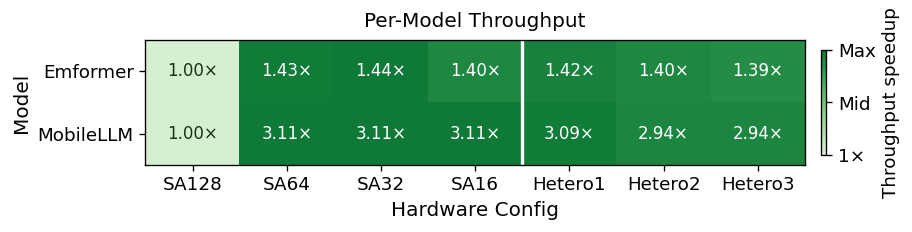

In [4]:
# ── Fig 6 : Deadline miss rate heatmap (latency models) ───────────────────────
# ── Fig 7 : Throughput heatmap (throughput / best-effort models) ───────────────
# Same policy selection as Fig 5.
# Miss rate heatmap : lower miss rate → darker green  (invert normalization per row).
# Throughput heatmap: speedup over mono128 (SA128 = 1×), higher → darker green.

from matplotlib.colors import LinearSegmentedColormap

HEATMAP_LP = {
    'mono128':   'deadline_deadline_fold',
    'comp4x64':  'deadline_deadline_fold',
    'comp16x32': 'deadline_deadline_fold',
    'comp64x16': 'deadline_deadline_fold',
    'hetero1':   'deadline_hetero_W50',
    'hetero2':   'deadline_hetero_W50',
    'hetero3':   'deadline_hetero_W50',
}

LAT_MODEL_ORDER = ['eyecod', 'hand_pose', 'key_res15', 'tcn', 'd2go', 'deit_small']
LAT_MODEL_LABELS = {
    'eyecod':     'EyeCod',     'hand_pose':  'HandPose',
    'key_res15':  'KeyRes15',   'tcn':        'TCN',
    'd2go':       'D2Go',       'deit_small': 'DeiT-Small',
}

TP_MODEL_ORDER  = ['emformer', 'mobilellm_125m']
TP_MODEL_LABELS = {'emformer': 'Emformer', 'mobilellm_125m': 'MobileLLM'}

green_mid = LinearSegmentedColormap.from_list(
    'green_mid', plt.cm.Greens(np.linspace(0.18, 0.82, 256))
)

def _annotate(ax, data_norm, data_actual, model_order, fmt_fn, threshold=0.55):
    for i in range(len(model_order)):
        for j in range(len(ALL_HW_ORDER)):
            v_norm   = data_norm[i, j]
            v_actual = data_actual[i, j]
            txt_color = 'white' if v_norm > threshold else '#163516'
            ax.text(j, i, fmt_fn(v_actual), ha='center', va='center',
                    fontsize=10, color=txt_color)

def _axis_labels(ax, model_order, model_labels):
    ax.set_xticks(range(len(ALL_HW_ORDER)))
    ax.set_xticklabels([HW_LABELS[h] for h in ALL_HW_ORDER], fontsize=11)
    ax.set_yticks(range(len(model_order)))
    ax.set_yticklabels([model_labels[m] for m in model_order], fontsize=11)
    ax.axvline(len(HOMO_HW_ORDER) - 0.5, color='white', linewidth=2)

def _cbar(fig, ax, im, label):
    cb = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
    cb.set_label(label, fontsize=11)
    cb.set_ticks([0.0, 0.5, 1.0])
    return cb

# ── Fig 6 : Miss rate ─────────────────────────────────────────────────────────
miss_cols = {}
for hw, lp_key in HEATMAP_LP.items():
    sub = trace[(trace['hardware'] == hw) & (trace['lp_key'] == lp_key)
                & (trace['mode'] == 'latency')]
    miss_cols[hw] = sub.groupby('model')['deadline_miss'].mean() * 100

miss_df  = pd.DataFrame(miss_cols).reindex(index=LAT_MODEL_ORDER, columns=ALL_HW_ORDER)
miss_arr = miss_df.values.astype(float)

# Invert: lower miss rate → higher normalised value → darker green
row_min_m = miss_arr.min(axis=1, keepdims=True)
row_max_m = miss_arr.max(axis=1, keepdims=True)
denom_m   = np.where(row_max_m > row_min_m, row_max_m - row_min_m, 1.0)
miss_norm = 1.0 - (miss_arr - row_min_m) / denom_m

fig6, ax6 = plt.subplots(figsize=(8, 3.5))
im6 = ax6.imshow(miss_norm, cmap=green_mid, aspect='auto', vmin=0.0, vmax=1.0)
_annotate(ax6, miss_norm, miss_arr, LAT_MODEL_ORDER,
          fmt_fn=lambda v: f'{v:.1f}%')
_axis_labels(ax6, LAT_MODEL_ORDER, LAT_MODEL_LABELS)

cb6 = _cbar(fig6, ax6, im6, 'Relative miss rate per model') #  (per-row normalized)
cb6.set_ticklabels(['High', 'Mid', 'Low'])

ax6.set_title(
    'Per-Model Deadline Miss Rate',
    # 'Darker green = fewer misses  |  Policy: deadline_task_aware + deadline_fold',e — Latency-Sensitive Models\n
    fontsize=12, pad=8,
)
ax6.set_xlabel('Hardware Config', fontsize=12)
ax6.set_ylabel('Model', fontsize=12)

plt.tight_layout(pad=0.8)
plt.savefig('outputs/miss_rate_heatmap.pdf', bbox_inches='tight')
plt.show()

# ── Fig 7 : Throughput (speedup over mono128) ─────────────────────────────────
tp_cols = {}
for hw, lp_key in HEATMAP_LP.items():
    sub = trace[(trace['hardware'] == hw) & (trace['lp_key'] == lp_key)
                & (trace['mode'] == 'throughput')]
    tp_cols[hw] = sub.groupby('model').size() / DURATION_S

tp_df   = pd.DataFrame(tp_cols).reindex(index=TP_MODEL_ORDER, columns=ALL_HW_ORDER)
mono_tp = tp_df['mono128'].values.reshape(-1, 1)
tp_arr  = (tp_df.values / mono_tp).astype(float)   # mono128 col → 1.00×

# Per-row normalize for color (higher speedup → darker green)
row_min_t = tp_arr.min(axis=1, keepdims=True)
row_max_t = tp_arr.max(axis=1, keepdims=True)
denom_t   = np.where(row_max_t > row_min_t, row_max_t - row_min_t, 1.0)
tp_norm   = (tp_arr - row_min_t) / denom_t

fig7, ax7 = plt.subplots(figsize=(8, 2))
im7 = ax7.imshow(tp_norm, cmap=green_mid, aspect='auto', vmin=0.0, vmax=1.0)
_annotate(ax7, tp_norm, tp_arr, TP_MODEL_ORDER,
          fmt_fn=lambda v: f'{v:.2f}×')
_axis_labels(ax7, TP_MODEL_ORDER, TP_MODEL_LABELS)

cb7 = _cbar(fig7, ax7, im7, 'Throughput speedup') # over mono128  (per-row normalized)')
cb7.set_ticklabels(['1×', 'Mid', 'Max'])

ax7.set_title(
    'Per-Model Throughput',
    # 'Speedup over mono128 (1×SA128)  |  Policy: deadline_task_aware + deadline_fold', — Best-Effort / Throughput Models\n
    fontsize=12, pad=8,
)
ax7.set_xlabel('Hardware Config', fontsize=12)
ax7.set_ylabel('Model', fontsize=12)

plt.tight_layout(pad=0.8)
plt.savefig('outputs/throughput_heatmap.pdf', bbox_inches='tight')
plt.show()
